In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/aslanahmedov/walmart-sales-forecast/features.csv
/kaggle/input/datasets/aslanahmedov/walmart-sales-forecast/stores.csv
/kaggle/input/datasets/aslanahmedov/walmart-sales-forecast/train.csv
/kaggle/input/datasets/aslanahmedov/walmart-sales-forecast/test.csv


In [2]:
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)

In [3]:
train = pd.read_csv('/kaggle/input/datasets/aslanahmedov/walmart-sales-forecast/train.csv')
print(train.shape)
train.head()

(421570, 5)


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [4]:
print('number of unique stores: ', train['Store'].nunique())
print('number of unique departments: ', train['Dept'].nunique())
print('date range ', train['Date'].min() ,' to ', train['Date'].max())
print('number of unique dates: ', train['Date'].nunique())

number of unique stores:  45
number of unique departments:  81
date range  2010-02-05  to  2012-10-26
number of unique dates:  143


The "expected vs actual" comparison tells us how incomplete the data is — if every store had every department every week; the real count being lower tells us there are real gaps (some departments simply don't exist in some stores, which is realistic — not every store carries every product category).

In [5]:
print(train['Date'].dtype)
print('Expected combinations if complete:', train['Store'].nunique() * train['Dept'].nunique() * train['Date'].nunique())
print('Actual rows:', len(train))

object
Expected combinations if complete: 521235
Actual rows: 421570


In [6]:
train['Date']= pd.to_datetime(train['Date'])
print(train['Date'].dtype)

datetime64[ns]


In [7]:
dept_counts_per_store = train.groupby('Store')['Dept'].nunique()
print(dept_counts_per_store.describe())

count    45.000000
mean     74.022222
std       5.654800
min      61.000000
25%      74.000000
50%      77.000000
75%      77.000000
max      79.000000
Name: Dept, dtype: float64


tores have anywhere from **61 to 79** unique departments, averaging around **74**. Since the max possible is 81 (the total unique departments across the whole dataset), this confirms our theory directly: no store has all 81 departments, and it genuinely varies store to store (some carry as few as 61)

In [8]:
print(train.isnull().sum())
print()
print('negative sales: ', (train['Weekly_Sales']<0).sum())
print('zero sales: ', (train['Weekly_Sales']==0).sum())
print()
print(train['Weekly_Sales'].describe())

Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
dtype: int64

negative sales:  1285
zero sales:  73

count    421570.000000
mean      15981.258123
std       22711.183519
min       -4988.940000
25%        2079.650000
50%        7612.030000
75%       20205.852500
max      693099.360000
Name: Weekly_Sales, dtype: float64


**Negative sales:** 1,285 rows (~0.3% of data). As suspected, this is realistic in retail — a plausible explanation is that a store's returns/refunds exceeded new purchases for that department that week

In [9]:
train[train['Weekly_Sales']<0].sort_values('Weekly_Sales').head(10)

,Store,Dept,Date,Weekly_Sales,IsHoliday
267730,28,6,2010-10-08,-4988.94,False
336495,35,47,2011-09-02,-3924.00,False
417801,45,47,2010-02-26,-1750.00,False
153916,16,47,2012-03-09,-1699.00,False
271300,28,32,2011-03-25,-1321.48,False
16291,2,47,2010-07-30,-1098.00,False
16295,2,47,2010-10-15,-1098.00,False
16297,2,47,2010-11-19,-1098.00,False
24830,3,32,2011-09-30,-1008.96,False
35561,4,47,2010-09-17,-898.00,False


None of these are flagged **IsHoliday = True** — so it's not clustering around major shopping holidays like we might've guessed.

**Department 47** shows up repeatedly (5 of these 10 rows), and **Store 2, Dept 47 has the exact same value, -$1,098.00, on three different dates** (7/30, 10/15, 11/19 2010) — that's suspicious. A recurring identical negative value for the same store-department combination looks less like organic "returns exceeded sales" and more like either a data entry pattern specific to that department, or possibly a recurring adjustment/correction being logged in the data.

In [10]:
train[train['Dept']==47]['Weekly_Sales'].describe()
print()
print('Negative sales in Dept 47:', (train[train['Dept'] == 47]['Weekly_Sales'] < 0).sum())
print('total rows in dept 47: ',len(train[train['Dept']==47]))


Negative sales in Dept 47: 254
total rows in dept 47:  646


**39%** of Department 47's rows are negative sales (254 out of 646), versus just 0.3% negative across the whole dataset

In [11]:
dept_negative_prct= train.groupby('Dept').apply(lambda x: (x['Weekly_Sales']<0).mean()*100)
dept_negative_prct.sort_values(ascending=False).head(10)

/tmp/ipykernel_58/2429946470.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dept_negative_prct= train.groupby('Dept').apply(lambda x: (x['Weekly_Sales']<0).mean()*100)


Dept
47    39.318885
78    14.042553
77    10.666667
18     3.579240
54     3.062723
19     2.112163
51     1.793400
49     1.494868
94     1.354442
45     1.239669
dtype: float64

**Investigating: **plot Dept 47's sales over time to see if there's an obvious pattern (like a fixed cycle of returns) before deciding.

In [12]:
dept47 = train[train['Dept']==47]
print(dept47['Store'].unique())

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 31 32 34 35 39 40 41 45]


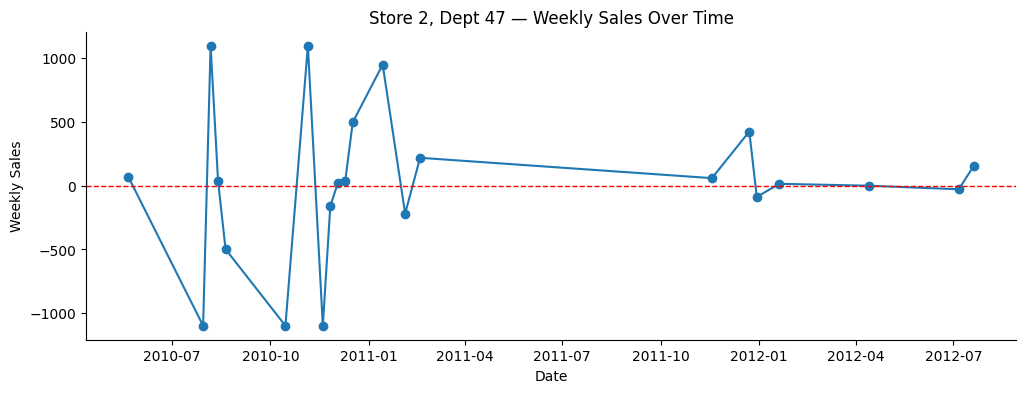

In [13]:
store2_dept47 = train[(train['Store'] == 2) & (train['Dept'] == 47)].sort_values('Date')

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(store2_dept47['Date'], store2_dept47['Weekly_Sales'], marker='o')
ax.axhline(0, color='red', linestyle='--', linewidth=1)
ax.set_title('Store 2, Dept 47 — Weekly Sales Over Time')
ax.set_xlabel('Date')
ax.set_ylabel('Weekly Sales')
ax.grid(False)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.show()

Dept 47 isn't "noisy but still a real ongoing product line", it looks more like a department that existed early in the dataset's timeframe and effectively disappeared

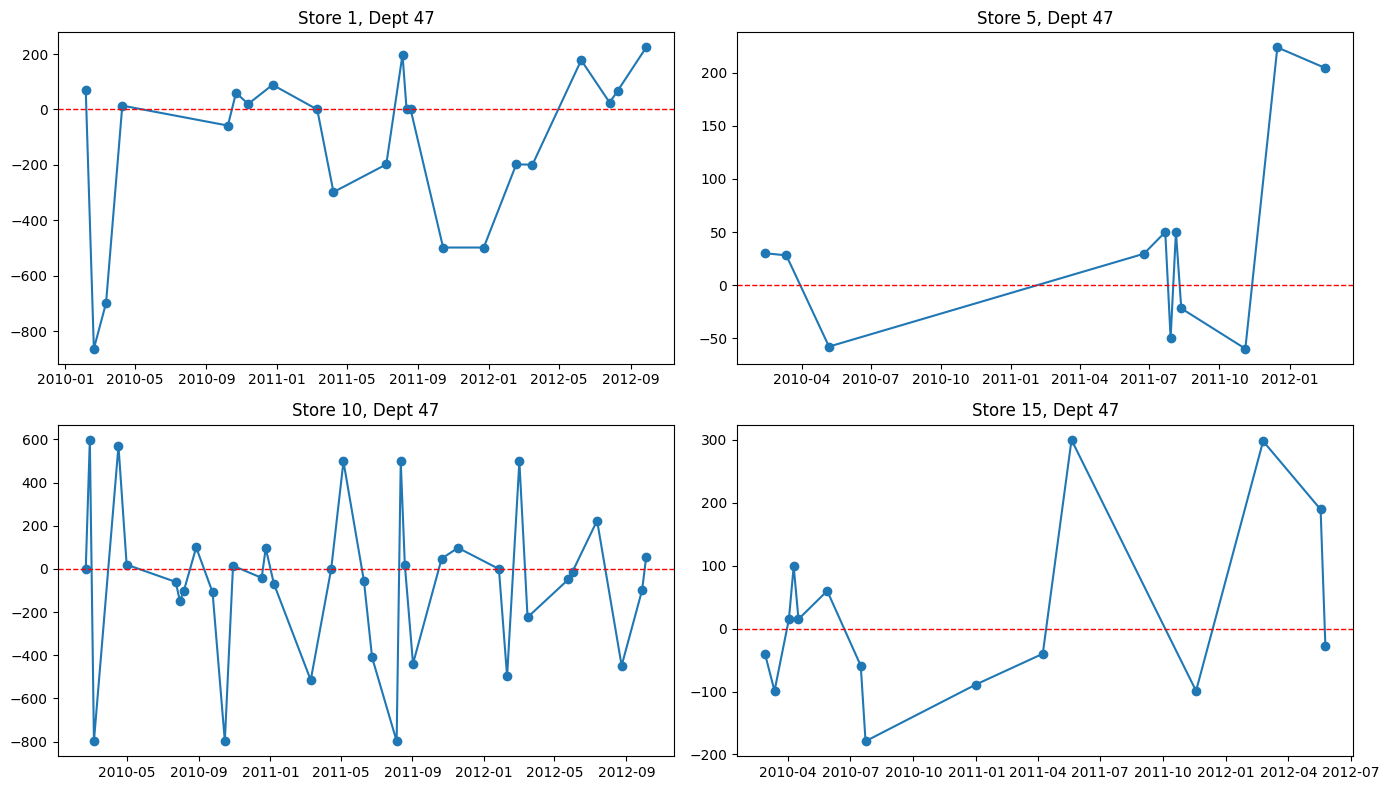

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

sample_stores = [1, 5, 10, 15]

for ax, store_num in zip(axes.flat, sample_stores):
    subset = train[(train['Store'] == store_num) & (train['Dept'] == 47)].sort_values('Date')
    ax.plot(subset['Date'], subset['Weekly_Sales'], marker='o')
    ax.axhline(0, color='red', linestyle='--', linewidth=1)
    ax.set_title(f'Store {store_num}, Dept 47')
    ax.grid(False)

plt.tight_layout()
plt.show()

In [15]:
for dept_num in [78, 77]:
    subset = train[train['Dept'] == dept_num]
    print(f"Dept {dept_num}: {len(subset)} rows, {(subset['Weekly_Sales'] < 0).mean()*100:.1f}% negative")

Dept 78: 235 rows, 14.0% negative
Dept 77: 150 rows, 10.7% negative


**Exclude Department 47 from the forecasting model**:

-39% negative sales rate (vs. <2% for almost every other department)

-Erratic, inconsistent behavior across stores (no shared, learnable pattern)

-No plausible way to explain or predict this department's future values from pastvalues in a way a normal forecasting model would trust-

In [16]:
train_clean = train[train['Dept'] != 47].copy()

print('Original rows:', len(train))
print('After excluding Dept 47:', len(train_clean))
print('Rows removed:', len(train) - len(train_clean))

Original rows: 421570
After excluding Dept 47: 420924
Rows removed: 646


In [17]:
stores = pd.read_csv('/kaggle/input/datasets/aslanahmedov/walmart-sales-forecast/stores.csv')
print(stores.shape)

stores.head(10)

(45, 3)


,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875
5,6,A,202505
6,7,B,70713
7,8,A,155078
8,9,B,125833
9,10,B,126512


In [18]:
print(stores['Type'].value_counts())
print()
print(stores.groupby('Type')['Size'].describe())

Type
A    22
B    17
C     6
Name: count, dtype: int64

      count           mean           std      min        25%       50%  \
Type                                                                     
A      22.0  177247.727273  49392.621098  39690.0  155840.75  202406.0   
B      17.0  101190.705882  32371.137916  34875.0   93188.00  114533.0   
C       6.0   40541.666667   1304.145033  39690.0   39745.00   39910.0   

           75%       max  
Type                      
A     203819.0  219622.0  
B     123737.0  140167.0  
C      40774.0   42988.0  


Type is essentially a categorical shorthand for store size tier — largest, medium, smallest.

In [19]:
features = pd.read_csv('/kaggle/input/datasets/aslanahmedov/walmart-sales-forecast/features.csv')

print(features.shape)
features.head()

(8190, 12)


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [20]:
print(features.isnull().sum())
print()
print('Date range:', features['Date'].min(), 'to', features['Date'].max())
print()
# Check if MarkDown columns have nulls only in early dates
features['Date'] = pd.to_datetime(features['Date'])
print(features.groupby(features['Date'].dt.year)['MarkDown1'].apply(lambda x: x.isnull().mean() * 100))

Store              0
Date               0
Temperature        0
Fuel_Price         0
MarkDown1       4158
MarkDown2       5269
MarkDown3       4577
MarkDown4       4726
MarkDown5       4140
CPI              585
Unemployment     585
IsHoliday          0
dtype: int64

Date range: 2010-02-05 to 2013-07-26

Date
2010    100.000000
2011     84.871795
2012      0.427350
2013      0.148148
Name: MarkDown1, dtype: float64


2010: 100% missing — markdowns weren't tracked at all

2011: 84.9% missing — the program was clearly being rolled out mid-year, partial tracking

2012 onward: under 1% missing — fully tracked, essentially complete

This means the right interpretation is: NaN = "not tracked yet", not NaN = "no promotion happened."

In [21]:
print(features.groupby(features['Date'].dt.year)['CPI'].apply(lambda x: x.isnull().mean() * 100))

Date
2010     0.000000
2011     0.000000
2012     0.000000
2013    43.333333
Name: CPI, dtype: float64


In [22]:
features[features['CPI'].isnull()]['Date'].dt.to_period('M').value_counts().sort_index()

Date
2013-05    225
2013-06    180
2013-07    180
Freq: M, Name: count, dtype: int64

CPI/Unemployment NaNs = "real values exist in the world, we just don't have them recorded yet" → filling with 0 would be actively wrong (CPI is never 0, that's a nonsensical value) — better to fill using the most recent known value for that store (a technique called forward-fill), since these economic indicators don't change dramatically week to week.

In [23]:
features = features.sort_values(['Store', 'Date'])

features['CPI'] = features.groupby('Store')['CPI'].ffill()
features['Unemployment'] = features.groupby('Store')['Unemployment'].ffill()

print(features[['CPI', 'Unemployment']].isnull().sum())

CPI             0
Unemployment    0
dtype: int64


In [24]:
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']

features[markdown_cols] = features[markdown_cols].fillna(0)

print(features[markdown_cols].isnull().sum())

MarkDown1    0
MarkDown2    0
MarkDown3    0
MarkDown4    0
MarkDown5    0
dtype: int64


In [25]:
print(features.isnull().sum())

Store           0
Date            0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
IsHoliday       0
dtype: int64


# Mergin the files

In [26]:
df = train_clean.merge(stores, on='Store', how='left')
df = df.merge(features, on=['Store', 'Date'], how='left')

In [27]:
print(df.shape)
df.head()

(420924, 17)


,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,False
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,True
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,False
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,False
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,False


In [28]:
print((df['IsHoliday_x'] == df['IsHoliday_y']).value_counts())

print()
df[df['IsHoliday_x'] != df['IsHoliday_y']].head()

True    420924
Name: count, dtype: int64



,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y


In [29]:
df = df.drop(columns=['IsHoliday_y'])
df = df.rename(columns={'IsHoliday_x': 'IsHoliday'})

df.columns.tolist()

['Store',
 'Dept',
 'Date',
 'Weekly_Sales',
 'IsHoliday',
 'Type',
 'Size',
 'Temperature',
 'Fuel_Price',
 'MarkDown1',
 'MarkDown2',
 'MarkDown3',
 'MarkDown4',
 'MarkDown5',
 'CPI',
 'Unemployment']

# EDA

**Overall weekly sales trend over time**

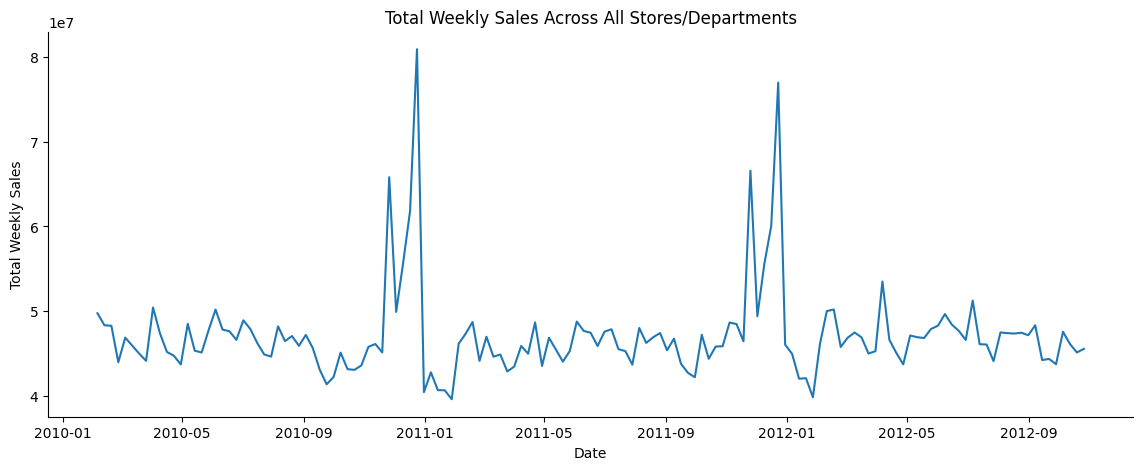

In [30]:
weekly_total = df.groupby('Date')['Weekly_Sales'].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(weekly_total['Date'], weekly_total['Weekly_Sales'])
ax.set_title('Total Weekly Sales Across All Stores/Departments')
ax.set_xlabel('Date')
ax.set_ylabel('Total Weekly Sales')
ax.grid(False)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.show()

In [31]:
weekly_total['IsHoliday'] = df.groupby('Date')['IsHoliday'].first().values  # each date has one holiday flag, same for all rows that week

print(weekly_total.groupby('IsHoliday')['Weekly_Sales'].mean())
print()
print(weekly_total.sort_values('Weekly_Sales', ascending=False).head(5))

IsHoliday
False    4.685658e+07
True     5.052993e+07
Name: Weekly_Sales, dtype: float64

         Date  Weekly_Sales  IsHoliday
46 2010-12-24   80930537.60      False
98 2011-12-23   76998567.39      False
94 2011-11-25   66593605.26       True
42 2010-11-26   65821102.24       True
45 2010-12-17   61819555.88      False


In [32]:
weekly_total[weekly_total['Date'].dt.month == 12]

,Date,Weekly_Sales,IsHoliday
43,2010-12-03,49909268.88,False
44,2010-12-10,55667291.39,False
45,2010-12-17,61819555.88,False
46,2010-12-24,80930537.60,False
47,2010-12-31,40433118.00,True
95,2011-12-02,49390439.49,False
96,2011-12-09,55560296.10,False
97,2011-12-16,60084163.97,False
98,2011-12-23,76998567.39,False
99,2011-12-30,46044073.54,True


In [33]:
df['Date'] = pd.to_datetime(df['Date'])

# The actual pre-Christmas peak weeks in this dataset
true_holiday_dates = pd.to_datetime(['2010-12-24', '2011-12-23'])

df['IsHoliday_corrected'] = df['IsHoliday'] | df['Date'].isin(true_holiday_dates)

# Confirm the fix
check = df[df['Date'].dt.month == 12].groupby('Date')[['IsHoliday', 'IsHoliday_corrected']].first()
print(check)

            IsHoliday  IsHoliday_corrected
Date                                      
2010-12-03      False                False
2010-12-10      False                False
2010-12-17      False                False
2010-12-24      False                 True
2010-12-31       True                 True
2011-12-02      False                False
2011-12-09      False                False
2011-12-16      False                False
2011-12-23      False                 True
2011-12-30       True                 True


**How does store Type relate to sales?**

In [34]:
print(df.groupby('Type')['Weekly_Sales'].mean())
print()
print(df.groupby('Type')['Weekly_Sales'].sum())

Type
A    20133.008538
B    12258.712100
C     9519.532538
Name: Weekly_Sales, dtype: float64

Type
A    4.331013e+09
B    2.000708e+09
C    4.055035e+08
Name: Weekly_Sales, dtype: float64


**checking the external features — correlation with sales**

In [35]:
numeric_cols = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
                'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']

df[numeric_cols].corr()['Weekly_Sales'].sort_values(ascending=False)

Weekly_Sales    1.000000
MarkDown5       0.050531
MarkDown1       0.047292
MarkDown3       0.038500
MarkDown4       0.037559
MarkDown2       0.020970
Fuel_Price     -0.000295
Temperature    -0.002554
CPI            -0.020932
Unemployment   -0.025836
Name: Weekly_Sales, dtype: float64

Every single correlation here is weak

**Why these correlations are misleadingly weak?**

Correlation measures a simple, straight-line (linear) relationship across the entire dataset. But we already know from Step 27-30 that markdowns and sales spikes are almost certainly concentrated in specific holiday weeks

a weak overall correlation doesn't necessarily mean a feature is useless — **it might mean the feature's effect is conditional** (only matters in certain situations)

In [36]:
holiday_weeks = df[df['IsHoliday_corrected'] == True]
non_holiday_weeks = df[df['IsHoliday_corrected'] == False]

print("Holiday weeks correlation:")
print(holiday_weeks[numeric_cols].corr()['Weekly_Sales'].sort_values(ascending=False))
print()
print("Non-holiday weeks correlation:")
print(non_holiday_weeks[numeric_cols].corr()['Weekly_Sales'].sort_values(ascending=False))

Holiday weeks correlation:
Weekly_Sales    1.000000
MarkDown3       0.075514
MarkDown5       0.054683
MarkDown4       0.007645
MarkDown1       0.007177
MarkDown2       0.006958
Fuel_Price      0.003119
Unemployment   -0.023555
Temperature    -0.024004
CPI            -0.025187
Name: Weekly_Sales, dtype: float64

Non-holiday weeks correlation:
Weekly_Sales    1.000000
MarkDown1       0.052561
MarkDown5       0.052112
MarkDown4       0.041167
MarkDown2       0.023719
MarkDown3       0.023617
Temperature     0.008399
Fuel_Price      0.003077
CPI            -0.020435
Unemployment   -0.026794
Name: Weekly_Sales, dtype: float64


Markdown variables show weak linear correlation with weekly sales overall, even when split by holiday period — likely due to zero-filled pre-2012 values diluting the signal, and/or non-linear interaction effects with store size/type that a simple correlation can't detect. We rely on tree-based models specifically because they can capture these more complex relationships.

**don't expect logistic-regression-style simplicity to win this time**

# feature engineering

**Extract calendar-based features from Date**

In [37]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['WeekOfYear'] = df['Date'].dt.isocalendar().week

df[['Date', 'Year', 'Month', 'WeekOfYear']].head()

,Date,Year,Month,WeekOfYear
0,2010-02-05,2010,2,5
1,2010-02-12,2010,2,6
2,2010-02-19,2010,2,7
3,2010-02-26,2010,2,8
4,2010-03-05,2010,3,9


**lag features**

In [38]:
df = df.sort_values(['Store', 'Dept', 'Date'])

df['Sales_Lag1'] = df.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(1)

df[['Store', 'Dept', 'Date', 'Weekly_Sales', 'Sales_Lag1']].head(10)

,Store,Dept,Date,Weekly_Sales,Sales_Lag1
0,1,1,2010-02-05,24924.50,NaN
1,1,1,2010-02-12,46039.49,24924.50
2,1,1,2010-02-19,41595.55,46039.49
3,1,1,2010-02-26,19403.54,41595.55
4,1,1,2010-03-05,21827.90,19403.54
5,1,1,2010-03-12,21043.39,21827.90
6,1,1,2010-03-19,22136.64,21043.39
7,1,1,2010-03-26,26229.21,22136.64
8,1,1,2010-04-02,57258.43,26229.21
9,1,1,2010-04-09,42960.91,57258.43


**Add a few more lag-based features — last year's same week, and a rolling average**

In [39]:
# Same week, one year ago - captures yearly seasonality directly (e.g., this Dec vs last Dec)
df['Sales_Lag52'] = df.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(52)

# Rolling average of the last 4 weeks - smooths out noise, captures recent trend
df['Sales_RollingMean4'] = df.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(1).rolling(4).mean()

df[['Store', 'Dept', 'Date', 'Weekly_Sales', 'Sales_Lag1', 'Sales_Lag52', 'Sales_RollingMean4']].head(10)

,Store,Dept,Date,Weekly_Sales,Sales_Lag1,Sales_Lag52,Sales_RollingMean4
0,1,1,2010-02-05,24924.50,NaN,NaN,NaN
1,1,1,2010-02-12,46039.49,24924.50,NaN,NaN
2,1,1,2010-02-19,41595.55,46039.49,NaN,NaN
3,1,1,2010-02-26,19403.54,41595.55,NaN,NaN
4,1,1,2010-03-05,21827.90,19403.54,NaN,32990.7700
5,1,1,2010-03-12,21043.39,21827.90,NaN,32216.6200
6,1,1,2010-03-19,22136.64,21043.39,NaN,25967.5950
7,1,1,2010-03-26,26229.21,22136.64,NaN,21102.8675
8,1,1,2010-04-02,57258.43,26229.21,NaN,22809.2850
9,1,1,2010-04-09,42960.91,57258.43,NaN,31666.9175


since our data is weekly, shifting by 52 rows gets us "this same week, roughly one year ago." Given our earlier Christmas finding, this could be a genuinely powerful feature — it directly tells the model "last December, this exact department did $X in this exact week," which is a much more targeted seasonality signal than just knowing "it's December."

.shift(1).rolling(4).mean() — we shift first (so we don't include the current week in its own rolling average, which would be leakage), then take the average of the last 4 available weeks. This smooths out short-term noise and captures a "recent trend" signal, distinct from any single week's data.

One important consequence of these new features, worth flagging now: every row with NaN in Sales_Lag52 (roughly the first year of data, per store-department) won't be usable for training a model that includes this feature — we'll need to either drop those early rows, or train two model variants (one with, one without long-lag features). We'll make that call explicitly when we get to modeling.

In [40]:
print('Total rows:', len(df))
print('Rows with complete lag features:', df.dropna(subset=['Sales_Lag1', 'Sales_Lag52', 'Sales_RollingMean4']).shape[0])

Total rows: 420924
Rows with complete lag features: 261083


every row with NaN in Sales_Lag52 (roughly the first year of data, per store-department) won't be usable for training a model that includes this feature — we'll need to either drop those early rows, or train two model variants (one with, one without long-lag features). We'll make that call explicitly when we get to modeling.

In [42]:
df_model = df.dropna(subset=['Sales_Lag1', 'Sales_Lag52', 'Sales_RollingMean4']).copy()
print('Rows before:', len(df))
print('Rows after:', len(df_model))

Rows before: 420924
Rows after: 261083


# the train/test/validation split

For time-series forecasting, we must **split chronologically** — train on earlier weeks, test on later weeks — never randomly

In [43]:
test = pd.read_csv('/kaggle/input/datasets/aslanahmedov/walmart-sales-forecast/test.csv')

print(test.columns.tolist())
print(test.shape)

['Store', 'Dept', 'Date', 'IsHoliday']
(115064, 4)


In [44]:
print(df_model['Date'].min(), 'to', df_model['Date'].max())
print('Number of unique weeks:', df_model['Date'].nunique())

2011-02-04 00:00:00 to 2012-10-26 00:00:00
Number of unique weeks: 91


[ Train: earliest weeks ] → [ Validation: middle weeks ] → [ Test: most recent weeks ]
A common approach: roughly 70% train / 15% validation / 15% test.

In [45]:
unique_dates= sorted(df_model['Date'].unique())

n= len(unique_dates)
train_end_idx=int(n*0.70)
val_end_idx= int(n*0.85)

train_dates=unique_dates[:train_end_idx]
val_dates=unique_dates[train_end_idx:val_end_idx]
test_dates= unique_dates[val_end_idx:]

print('Train:', train_dates[0], 'to', train_dates[-1], f'({len(train_dates)} weeks)')
print('Validation:', val_dates[0], 'to', val_dates[-1], f'({len(val_dates)} weeks)')
print('Test:', test_dates[0], 'to', test_dates[-1], f'({len(test_dates)} weeks)')

Train: 2011-02-04 00:00:00 to 2012-04-13 00:00:00 (63 weeks)
Validation: 2012-04-20 00:00:00 to 2012-07-20 00:00:00 (14 weeks)
Test: 2012-07-27 00:00:00 to 2012-10-26 00:00:00 (14 weeks)


In [46]:
train_df = df_model[df_model['Date'].isin(train_dates)].copy()
val_df = df_model[df_model['Date'].isin(val_dates)].copy()
test_df = df_model[df_model['Date'].isin(test_dates)].copy()

print('Train rows:', len(train_df))
print('Validation rows:', len(val_df))
print('Test rows:', len(test_df))

Train rows: 179793
Validation rows: 40546
Test rows: 40744


**final feature set**

In [47]:
for split_df in [train_df, val_df, test_df]:
    split_df.drop(columns=['IsHoliday'], inplace=True)

train_df = pd.get_dummies(train_df, columns=['Type'], drop_first=True)
val_df = pd.get_dummies(val_df, columns=['Type'], drop_first=True)
test_df = pd.get_dummies(test_df, columns=['Type'], drop_first=True)

for col in ['Type_B', 'Type_C']:
    for split_df in [train_df, val_df, test_df]:
        if col not in split_df.columns:
            split_df[col] = 0

print(train_df.columns.tolist())

['Store', 'Dept', 'Date', 'Weekly_Sales', 'Size', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday_corrected', 'Year', 'Month', 'WeekOfYear', 'Sales_Lag1', 'Sales_Lag52', 'Sales_RollingMean4', 'Type_B', 'Type_C']


hot encode each split separately, then explicitly check that Type_B/Type_C exist in all three — this guards against a subtle bug where, say, if the validation set happened to have zero Type C stores in it, pd.get_dummies simply wouldn't create a Type_C column for that split at all, silently creating mismatched columns between train/val/test.

In [48]:
target = 'Weekly_Sales'
drop_cols = ['Date', 'Weekly_Sales']

X_train = train_df.drop(columns=drop_cols)
y_train = train_df[target]

X_val = val_df.drop(columns=drop_cols)
y_val = val_df[target]

X_test = test_df.drop(columns=drop_cols)
y_test = test_df[target]

print(X_train.columns.tolist())
print(X_train.shape, X_val.shape, X_test.shape)

['Store', 'Dept', 'Size', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday_corrected', 'Year', 'Month', 'WeekOfYear', 'Sales_Lag1', 'Sales_Lag52', 'Sales_RollingMean4', 'Type_B', 'Type_C']
(179793, 21) (40546, 21) (40744, 21)


# baseline before any real model — the "naive forecast"

In [49]:
from sklearn.metrics import mean_absolute_error

naive_pred = X_val['Sales_Lag1']

mae_naive = mean_absolute_error(y_val, naive_pred)
print('Naive baseline MAE:', mae_naive)

Naive baseline MAE: 1662.719299807626


In [50]:
print('Average weekly sales:', y_val.mean())
print('Naive MAE as % of average sales:', (mae_naive / y_val.mean()) * 100)

Average weekly sales: 16314.30475977902
Naive MAE as % of average sales: 10.191787662976989


# Random Forest

In [51]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

val_pred_rf = rf.predict(X_val)

mae_rf = mean_absolute_error(y_val, val_pred_rf)
print('Random Forest MAE:', mae_rf)
print('Improvement over naive baseline:', ((mae_naive - mae_rf) / mae_naive) * 100, '%')

Random Forest MAE: 1440.1989569106695
Improvement over naive baseline: 13.382916943509448 %


RandomForestRegressor, not RandomForestClassifier this time — we're predicting a continuous number (dollar amount), not a category, so this is a regression problem, not classification. n_jobs=-1 just tells it to use all available CPU cores to speed up training

**feature importance**

In [52]:
importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

importances

,feature,importance
17,Sales_Lag52,0.813082
16,Sales_Lag1,0.134468
18,Sales_RollingMean4,0.036815
1,Dept,0.001908
7,MarkDown3,0.001899
4,Fuel_Price,0.001526
10,CPI,0.001287
11,Unemployment,0.001268
3,Temperature,0.001239
15,WeekOfYear,0.001172


the model has essentially learned "the best predictor of this week's sales is what happened this same week last year."

But this also raises an important, honest question worth sitting with: if Sales_Lag52 is doing almost all the work, are IsHoliday_corrected, Month, and the markdown features actually adding real value, or are they just redundant with information Sales_Lag52 already captures?

**train a version without Sales_Lag52**

In [53]:
features_no_lag52 = [col for col in X_train.columns if col != 'Sales_Lag52']

rf_no_lag52 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_no_lag52.fit(X_train[features_no_lag52], y_train)

val_pred_no_lag52 = rf_no_lag52.predict(X_val[features_no_lag52])

mae_no_lag52 = mean_absolute_error(y_val, val_pred_no_lag52)
print('MAE without Sales_Lag52:', mae_no_lag52)
print('vs. MAE with Sales_Lag52:', mae_rf)

MAE without Sales_Lag52: 1573.8002079366647
vs. MAE with Sales_Lag52: 1440.1989569106695


Sales_Lag52 is genuinely valuable — losing it costs about $134 in extra error per prediction — but it's not irreplaceable. The other features (markdowns, month, holiday flag, department) do provide some real signal on their own, just far less than the direct "same week last year" number.

**ew different hyperparameter combinations, evaluating each on the validation set**

n_estimators (number of trees), max_depth (how deep each tree can grow — controls overfitting), and min_samples_leaf (minimum data points required in a final leaf — also controls overfitting

In [54]:
from sklearn.ensemble import RandomForestRegressor

param_options = [
    {'n_estimators': 100, 'max_depth': None, 'min_samples_leaf': 1},
    {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 1},
    {'n_estimators': 200, 'max_depth': 20, 'min_samples_leaf': 2},
    {'n_estimators': 300, 'max_depth': 15, 'min_samples_leaf': 5},
]

results = []

for params in param_options:
    model = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    val_pred = model.predict(X_val)
    mae = mean_absolute_error(y_val, val_pred)
    results.append({**params, 'val_mae': mae})
    print(params, '-> MAE:', mae)

results_df = pd.DataFrame(results)
results_df

{'n_estimators': 100, 'max_depth': None, 'min_samples_leaf': 1} -> MAE: 1440.1989569106695
{'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 1} -> MAE: 1434.7390594152323
{'n_estimators': 200, 'max_depth': 20, 'min_samples_leaf': 2} -> MAE: 1413.7862129192615
{'n_estimators': 300, 'max_depth': 15, 'min_samples_leaf': 5} -> MAE: 1387.9571047229213


,n_estimators,max_depth,min_samples_leaf,val_mae
0,100,NaN,1,1440.198957
1,200,NaN,1,1434.739059
2,200,20.0,2,1413.786213
3,300,15.0,5,1387.957105


In [55]:
param_options_v2 = [
   # {'n_estimators': 300, 'max_depth': 15, 'min_samples_leaf': 5},  # our current best, for reference
    {'n_estimators': 300, 'max_depth': 10, 'min_samples_leaf': 10},
    {'n_estimators': 400, 'max_depth': 12, 'min_samples_leaf': 8},
    {'n_estimators': 300, 'max_depth': 8, 'min_samples_leaf': 20},
]

results_v2 = []

for params in param_options_v2:
    model = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    val_pred = model.predict(X_val)
    mae = mean_absolute_error(y_val, val_pred)
    results_v2.append({**params, 'val_mae': mae})
    print(params, '-> MAE:', mae)

{'n_estimators': 300, 'max_depth': 10, 'min_samples_leaf': 10} -> MAE: 1393.308569484304
{'n_estimators': 400, 'max_depth': 12, 'min_samples_leaf': 8} -> MAE: 1385.5527311949427
{'n_estimators': 300, 'max_depth': 8, 'min_samples_leaf': 20} -> MAE: 1416.3923636570746


# evaluate the tuned model on the untouched test set

In [56]:
final_rf = RandomForestRegressor(n_estimators=400, max_depth=12, min_samples_leaf=8, random_state=42, n_jobs=-1)
final_rf.fit(X_train, y_train)

test_pred = final_rf.predict(X_test)
mae_test = mean_absolute_error(y_test, test_pred)

print('Final Test MAE:', mae_test)
print('Test MAE as % of average sales:', (mae_test / y_test.mean()) * 100)

Final Test MAE: 1274.7861394582094
Test MAE as % of average sales: 8.041767397863914


**Compute the naive baseline on the test set too, for a fair final comparison**

In [57]:
naive_pred_test = X_test['Sales_Lag1']
mae_naive_test = mean_absolute_error(y_test, naive_pred_test)

print('Naive baseline (test set) MAE:', mae_naive_test)
print('Final model improvement over naive:', ((mae_naive_test - mae_test) / mae_naive_test) * 100, '%')

Naive baseline (test set) MAE: 1506.239824268604
Final model improvement over naive: 15.366323548295725 %


# SOLUTION 2: 

Train two versions — a "short-history" model using only Sales_Lag1/RollingMean4/calendar features (usable on all rows, including newer store-departments with limited history), and a "full-history" model that adds Sales_Lag52 for cases where a full year of data exists — this mirrors a common real-world approach (new products/departments need a different model than established ones with years of history).

In [58]:
test_period_all_rows = df[df['Date'].isin(test_dates)]

print('Total rows in test period (before any dropna):', len(test_period_all_rows))
print('Rows missing Sales_Lag52 in test period:', test_period_all_rows['Sales_Lag52'].isnull().sum())

Total rows in test period (before any dropna): 41424
Rows missing Sales_Lag52 in test period: 680
